# Phase 3 / Day 4 — Building & Training a Network in Keras

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart_2020_cleaned.csv")
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [3]:
#dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [4]:
# Traget encoding
df["HeartDisease"] = df["HeartDisease"].map({"Yes":1, "No":0})

In [5]:
#seperating the target
x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

In [6]:
#splitting 80/20 the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=42)

In [7]:
#basic categorical features one-hot encoding
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

This pipeline intentionally uses light weight preprocessing : drop duplicates -> one-hot encode categoricals -> scale numericals, to keep this notebook **focused on the neural network mechanics** rather than feature engineering from the baseline project.

In [8]:
#numerical features scaling
numeric_to_Scale = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
scaler = StandardScaler()
x_train[numeric_to_Scale] = scaler.fit_transform(x_train[numeric_to_Scale])
x_test[numeric_to_Scale] = scaler.transform(x_test[numeric_to_Scale])
df.shape

(301717, 18)

**301,717 rows, 18 columns** remain after duplicate removal.

In [9]:
X_train_nn = x_train.astype(np.float32).values if hasattr(x_train, "values") else x_train.astype(np.float32)
X_test_nn = x_test.astype(np.float32).values if hasattr(x_test, "values") else x_test.astype(np.float32)
y_train_nn = y_train.astype(np.float32).values if hasattr(y_train, "values") else y_train.astype(np.float32)
y_test_nn = y_test.astype(np.float32).values if hasattr(y_test, "values") else y_test.astype(np.float32)

print(X_train_nn.shape, y_train_nn.shape)

(241373, 37) (241373,)


This column count comes from one-hot encoding every categorical  column with *drop_first=True*.

## Build the Sequential Model

In [10]:
n_features= X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761 (6.88 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)

A simple three-layer network: *37 inputs -> 32 ReLU units -> 1 sigmoid output*, totaling 1,761 trainable parameters. This is a small network by design, a larger network would risk overfitting a signal that earlier analysis already showed is largely weak and additive.

## Compile & Train

In [11]:
model.compile(
    optimizer ="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight("balanced", classes=np.unique(y_train_nn), y=y_train_nn)
class_weight_dict = {0:weights[0], 1:weights[1]}

history = model.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 444us/step - accuracy: 0.7159 - loss: 0.5325 - val_accuracy: 0.7382 - val_loss: 0.5012
Epoch 2/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - accuracy: 0.7304 - loss: 0.5019 - val_accuracy: 0.7291 - val_loss: 0.5055
Epoch 3/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.7284 - loss: 0.4983 - val_accuracy: 0.6984 - val_loss: 0.5536
Epoch 4/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.7274 - loss: 0.4962 - val_accuracy: 0.7239 - val_loss: 0.5089
Epoch 5/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7255 - loss: 0.4946 - val_accuracy: 0.7405 - val_loss: 0.4845
Epoch 6/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7264 - loss: 0.4935 - val_accuracy: 0.7378 - val_loss: 0.4863
Epoch 7/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - accuracy: 0.7275 - loss: 0.4923 - val_accuracy: 0.7385 - val_loss: 0.4829
Epoch 8/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7260 - loss: 0.4917 - 

Over 30 epochs, **training loss decreased smoothly and steadily** from 0.530 (epoch 1) to 0.482 (epoch30) with training accuracy holding flat around 0.73 throughout. This indicates that the network optimized consistently on the training data without difficulty.

## Plot & Diagnose

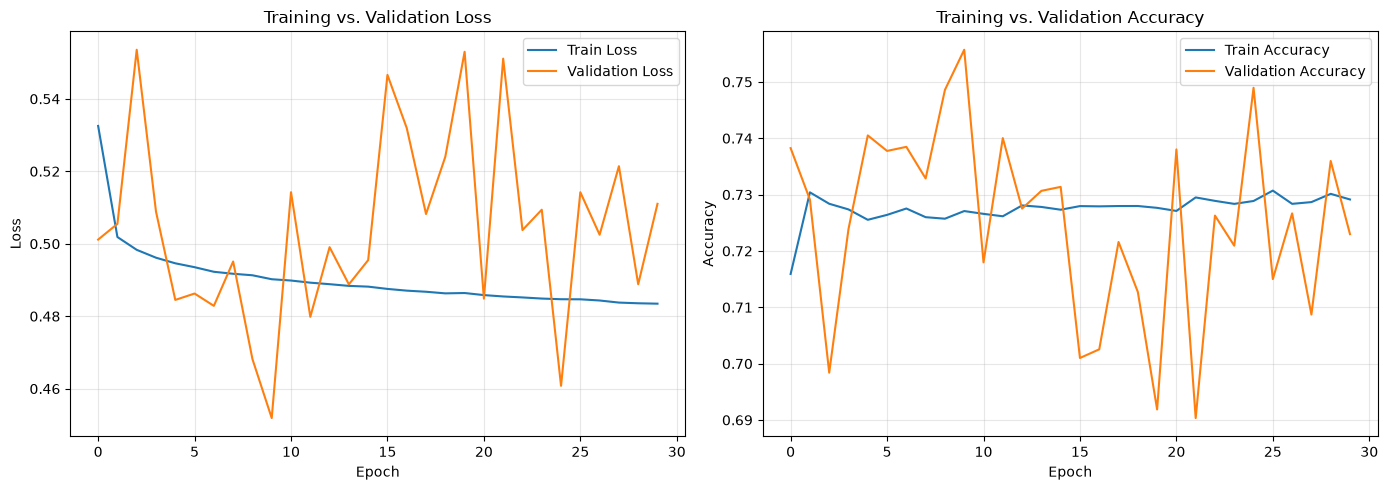

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")  
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs. Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs. Validation Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Fit Diagnosis

*The two curves reveal something beyond overfitting*

**Training loss and accuracy are generally smooth and stable**, loss declines steadily and accuracy holds arounf 0.73 with negligable fluctuations between epochs.

**Validation loss and accuracy are extremely noisy**, validaion loss swings between roughly 0.45 and 0.54 repeatidly across the 30 epochs with no consistent upward or danward trend. Validation accuracy correspondingly jumps between around 0.69 and 0.76 .

This is not the classic overfitting signature but points to **training instability** rather than memorization.

Likely contributers:
- The default Adam learning rate (0.001) combined with *class_weight="balanced"* can makke individual batches of the minority class. This can cause the model's decision boundary to shift more sharply between epochs than smooth training curve suggests.
- *batch_size=256* , a validation evaluation happens once per epoch, so alot of intra-epoch drift accumulates before it's measured.

## Add Dropout/Batch Normalization , comparison

#### Regularised model

In [13]:
model_reg = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_reg.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_reg = model_reg.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.6573 - loss: 0.6242 - val_accuracy: 0.7017 - val_loss: 0.5499
Epoch 2/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - accuracy: 0.7076 - loss: 0.5330 - val_accuracy: 0.7134 - val_loss: 0.5202
Epoch 3/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - accuracy: 0.7139 - loss: 0.5175 - val_accuracy: 0.6994 - val_loss: 0.5256
Epoch 4/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.7169 - loss: 0.5149 - val_accuracy: 0.7302 - val_loss: 0.4920
Epoch 5/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.7188 - loss: 0.5117 - val_accuracy: 0.7274 - val_loss: 0.4952
Epoch 6/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.7172 - loss: 0.5100 - val_accuracy: 0.7158 - val_loss: 0.5130
Epoch 7/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.7196 - loss: 0.5081 - val_accuracy: 0.6887 - val_loss: 0.5345
Epoch 8/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.7184 - loss: 0.5068 - 

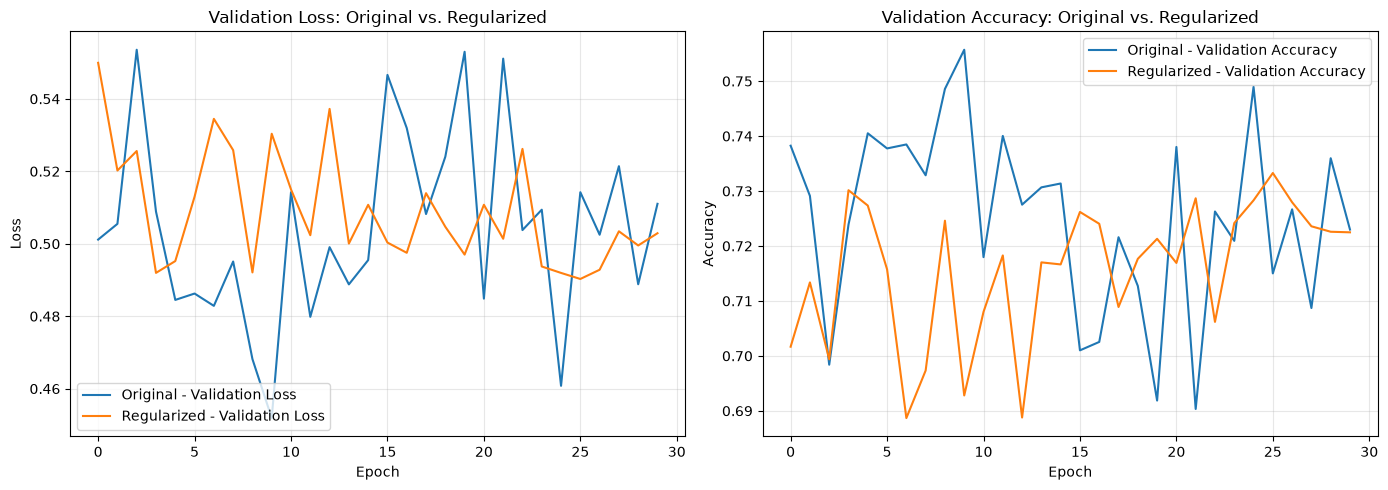

In [17]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(history.history["val_loss"], label="Original - Validation Loss")
axes[0].plot(history_reg.history["val_loss"], label="Regularized - Validation Loss")  
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Validation Loss: Original vs. Regularized")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["val_accuracy"], label="Original - Validation Accuracy")
axes[1].plot(history_reg.history["val_accuracy"], label="Regularized - Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy: Original vs. Regularized")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Comparison

Both original and regularized models show similarly wide validation loss oscilation across epochs - *Droput and Batch Normalization did not meaningfully stabilize training*. This suggests the instability isn't caused  by overfitting but more likely stems from the learning rate/ class_weight combination affecting both models equally.

## Evaluating on Test Set and Comparing to Baseline

In [15]:
from sklearn.metrics import roc_auc_score, classification_report

test_proba = model_reg.predict(X_test_nn).ravel()
test_pred = (test_proba >= 0.5).astype(int)

nn_roc_auc = roc_auc_score(y_test_nn, test_proba)
print("Neural Network ROC-AUC:", nn_roc_auc)
print(classification_report(y_test_nn, test_pred))

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 0s 152us/step
Neural Network ROC-AUC: 0.8351519553583214
              precision    recall  f1-score   support

         0.0       0.97      0.72      0.82     54892
         1.0       0.22      0.80      0.34      5452

    accuracy                           0.72     60344
   macro avg       0.60      0.76      0.58     60344
weighted avg       0.91      0.72      0.78     60344



#### Comparison to day 1 baseline

| Model | ROC-AUC |
|---|---|
| Logistic Regression - Baseline | 0.832 |
| Neural Network - Regularized model | 0.835 |

The Neural network marginally edges out the baseline, a modest but real improvement. The classification report shows high recall on the positive classes at the cost of low precision  tradeoff as a consequence of *class_weigth*.

This reinforces the conclusion that **the dataset's signal is largely linear**.